In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))
from scripts.common import add_galactic, mollweide_scatter

FILE_PATH = Path("../data/pantheon/DataRelease/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES.dat")

pantheon_survey_names = {
    1: 'SDSS', 4: 'SNLS', 5: 'CSP', 10: 'DES',
    15: 'PS1MD', 18: 'CNIa0.02', 50: 'LOWZ/JRK07', 51: 'LOSS1',
    56: 'SOUSA', 57: 'LOSS2', 61: 'CFA1', 62: 'CFA2',
    63: 'CFA3S', 64: 'CFA3K', 65: 'CFA4p2', 66: 'CFA4p3',
    100: 'HST', 101: 'SNAP', 106: 'CANDELS',
    150: 'FOUND'
}

pantheon_styles = {
    'SDSS':         {'color': '#1f77b4', 'marker': 'o'},
    'SNLS':         {'color': '#aec7e8', 'marker': 's'},
    'CSP':          {'color': '#ff7f0e', 'marker': '^'},
    'DES':          {'color': '#ffbb78', 'marker': 'D'},
    'PS1MD':        {'color': '#2ca02c', 'marker': 'v'},
    'CNIa0.02':     {'color': '#98df8a', 'marker': 'p'},
    'LOWZ/JRK07':   {'color': '#d62728', 'marker': 'h'},
    'LOSS1':        {'color': '#ff9896', 'marker': 'H'},
    'SOUSA':        {'color': '#9467bd', 'marker': '<'},
    'LOSS2':        {'color': '#c5b0d5', 'marker': '>'},
    'CFA1':         {'color': '#8c564b', 'marker': 'x'},
    'CFA2':         {'color': '#c49c94', 'marker': '+'},
    'CFA3S':        {'color': '#e377c2', 'marker': 'd'},
    'CFA3K':        {'color': '#f7b6d2', 'marker': '1'},
    'CFA4p2':       {'color': '#7f7f7f', 'marker': '2'},
    'CFA4p3':       {'color': '#c7c7c7', 'marker': '3'},
    'HST':          {'color': '#bcbd22', 'marker': '4'},
    'SNAP':         {'color': '#dbdb8d', 'marker': '8'},
    'CANDELS':      {'color': '#17becf', 'marker': '|'},
    'FOUND':        {'color': '#9edae5', 'marker': '*'},
    'Other':        {'color': '#393b79', 'marker': 'h'},
}

In [50]:
df = pd.read_csv(FILE_PATH, sep=r'\s+', comment='#')
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"\nColumns:\n{list(df.columns)}")

Loaded 1701 rows, 47 columns

Columns:
['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']


In [56]:
print("Survey distribution:")
survey_counts = df['IDSURVEY'].value_counts().sort_index()
for sid, count in survey_counts.items():
    print(f"  Survey {pantheon_survey_names[sid]}: {count:5d} entries")
print(f"\nUnique SNe (by CID): {df['CID'].nunique()}")

Survey distribution:
  Survey SDSS:   321 entries
  Survey SNLS:   160 entries
  Survey CSP:    89 entries
  Survey DES:   203 entries
  Survey PS1MD:   269 entries
  Survey CNIa0.02:    15 entries
  Survey LOWZ/JRK07:    46 entries
  Survey LOSS1:    48 entries
  Survey SOUSA:    57 entries
  Survey LOSS2:   105 entries
  Survey CFA1:    13 entries
  Survey CFA2:    24 entries
  Survey CFA3S:    34 entries
  Survey CFA3K:    58 entries
  Survey CFA4p2:    38 entries
  Survey CFA4p3:    12 entries
  Survey HST:    16 entries
  Survey SNAP:     6 entries
  Survey CANDELS:     8 entries
  Survey FOUND:   179 entries

Unique SNe (by CID): 1543


In [57]:
df['l'], df['b'] = add_galactic(df['RA'].values, df['DEC'].values)
print(f"Galactic coords added. Sample:\n{df[['CID', 'RA', 'DEC', 'l', 'b']].head()}")

Galactic coords added. Sample:
             CID       RA      DEC           l          b
0         2011fe  210.774  54.2737  101.983351  59.843384
1         2011fe  210.774  54.2737  101.983351  59.843384
2         2012cg  186.803   9.4203  283.894932  71.391070
3         2012cg  186.803   9.4203  283.894932  71.391070
4  1994DRichmond  188.510   7.7016  290.150586  70.140419


In [71]:
pd.cut(df['zHD'], [0.001, 0.1, 3]).value_counts()

zHD
(0.1, 3.0]      960
(0.001, 0.1]    741
Name: count, dtype: int64

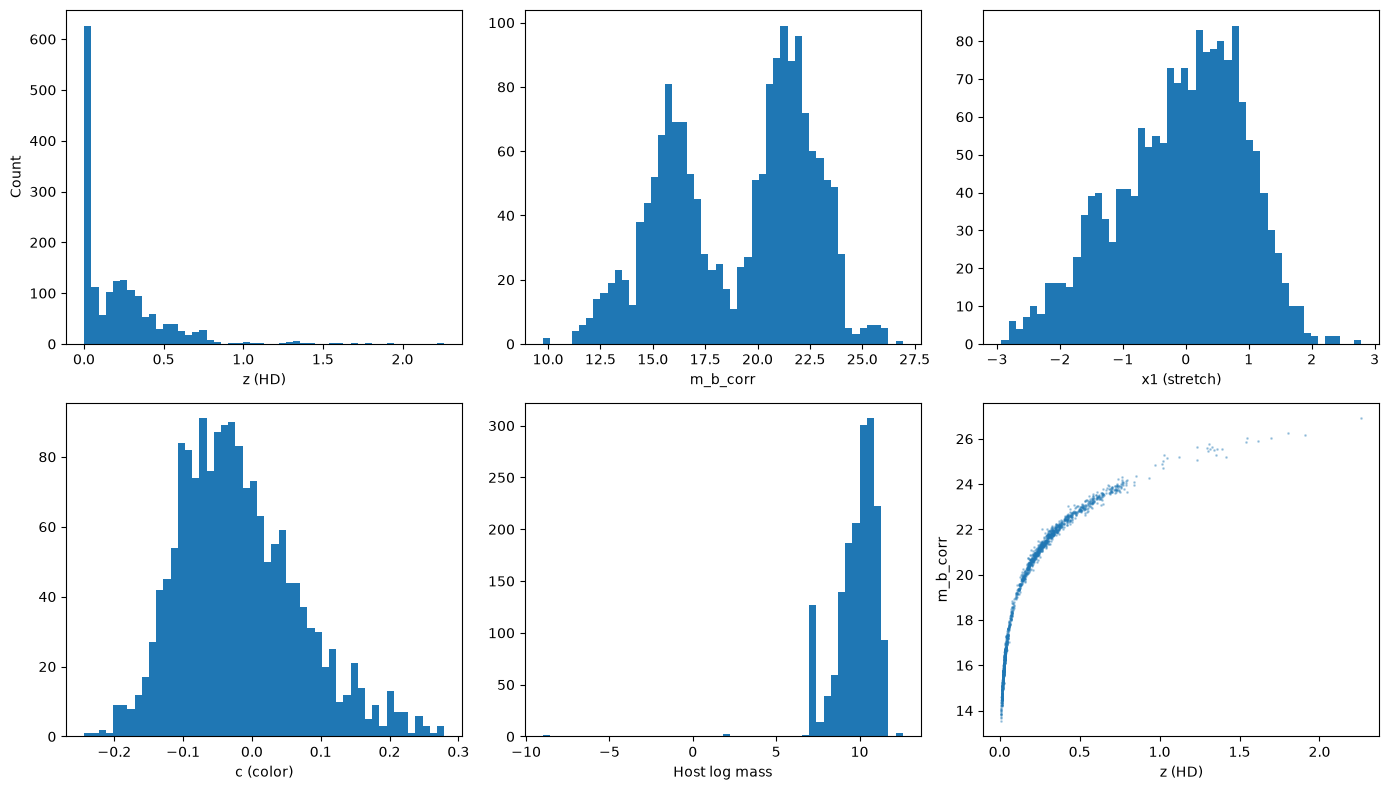

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(df['zHD'], bins=50)
axes[0, 0].set_xlabel("z (HD)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df['m_b_corr'], bins=50)
axes[0, 1].set_xlabel("m_b_corr")

axes[0, 2].hist(df['x1'], bins=50)
axes[0, 2].set_xlabel("x1 (stretch)")

axes[1, 0].hist(df['c'], bins=50)
axes[1, 0].set_xlabel("c (color)")

mass = df['HOST_LOGMASS'].dropna()
axes[1, 1].hist(mass, bins=50)
axes[1, 1].set_xlabel("Host log mass")

good = df['zHD'] > 0.01
axes[1, 2].scatter(df.loc[good, 'zHD'], df.loc[good, 'm_b_corr'], s=1, alpha=0.3)
axes[1, 2].set_xlabel("z (HD)")
axes[1, 2].set_ylabel("m_b_corr")

plt.tight_layout()
plt.show()

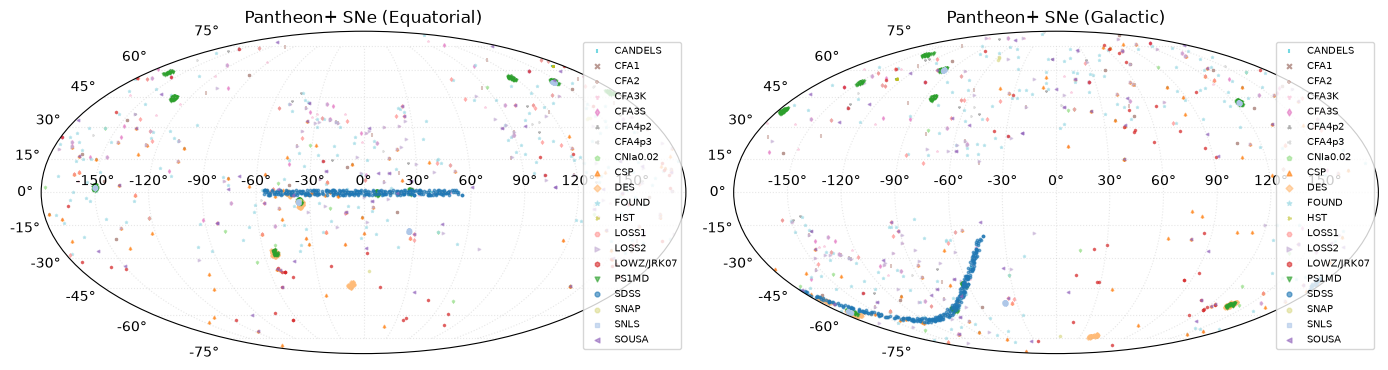

In [54]:
df['survey_name'] = df['IDSURVEY'].map(pantheon_survey_names).fillna('Other')

fig = plt.figure(figsize=(14, 6))
ax0 = plt.subplot(1, 2, 1, projection='mollweide')
mollweide_scatter(ax0, df['RA'], df['DEC'], df['survey_name'], pantheon_styles,
                  'Pantheon+ SNe (Equatorial)')

ax1 = plt.subplot(1, 2, 2, projection='mollweide')
mollweide_scatter(ax1, df['l'], df['b'], df['survey_name'], pantheon_styles,
                  'Pantheon+ SNe (Galactic)')
plt.tight_layout()
plt.show()

In [55]:
print("=== Summary Statistics ===")
print(f"Total rows: {len(df)}, Unique SNe: {df["CID"].nunique()}")
print(f"Redshift range: {df["zCMB"].min():.4f} - {df["zCMB"].max():.4f}")
print(f"Surveys: {df["IDSURVEY"].nunique()}")
print(f"Mean corrected magnitude: {df["m_b_corr"].mean():.3f}")

=== Summary Statistics ===
Total rows: 1701, Unique SNe: 1543
Redshift range: 0.0012 - 2.2613
Surveys: 20
Mean corrected magnitude: 19.084
